Cs de # 🔍 Minería de Datos — Clase 2: Exploración y Preparación de Datos

Politécnico Malvinas Argentinas | Tecnicatura en Ds de Datos e IA | 2026

Materia: Minería de Datos
Tipo: Clase Práctica (Clase 2)

Tema: Análisis Exploratorio de Datos (EDA) con pandas

In [21]:
# Verificar versiones de las librerías principales
#!pip install pandas==3.0
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
# Carga del dataset desde seaborn (ya disponible en Colab)
df2 = sns.load_dataset('tips')     # Propinas en restaurante
#1 Carga y dimensiones
#Vista previa de las primeras con head() y shape para ver cantidad de filas y columnas
print(f'Dataset cargado: {df2.shape[0]} filas × {df2.shape[1]} columnas')
print('\nPrimeras 5 filas:')
df2.head()

Dataset cargado: 244 filas × 7 columnas

Primeras 5 filas:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# Información general del dataset
print('Información del dataset:')
df2.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
# ─── COMANDO 2: describe() ──────────────────────────────────────────────────
# Estadística descriptiva: count, mean, std, min, 25%, 50% (mediana), 75%, max
# Por defecto solo columnas numéricas
print('Estadística descriptiva — variables numéricas:')
df2.describe()

Estadística descriptiva — variables numéricas:


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
# Describe también funciona para variables categóricas
# unique: cantidad de valores únicos | top: valor más frecuente | freq: frecuencia del top
print('Estadística descriptiva — TODAS las variables:')
df2.describe(include='all')

Estadística descriptiva — TODAS las variables:


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


In [27]:
# ─── COMANDO 3: isnull().sum() ──────────────────────────────────────────────
# Cuenta cuántos NaN (Not a Number) hay en cada columna
missing = df2.isnull().sum()
pct_missing = (missing / len(df2) * 100).round(1)

# Crear tabla resumen de faltantes
resumen_faltantes = pd.DataFrame({
    'Valores faltantes': missing,
    '% del total': pct_missing
})

# Mostrar solo columnas con faltantes, ordenadas
print('Columnas con valores faltantes:')
resumen_faltantes[resumen_faltantes['Valores faltantes'] > 0].sort_values('% del total', ascending=False)

Columnas con valores faltantes:


,Valores faltantes,% del total


Como podemos observar, no tenemos valores faltantes.

In [10]:
# ─── COMANDO: Frecuencia por intervalos en tip ─────────────────────────────

# Crear intervalos (bins)
df2['tip_bins'] = pd.cut(df2['tip'], bins=5)

print('Distribución de tip por intervalos (frecuencia absoluta):')
print(df2['tip_bins'].value_counts().sort_index())
print()

print('Proporción:')
print(df2['tip_bins'].value_counts(normalize=True).sort_index().round(3))

Distribución de tip por intervalos (frecuencia absoluta):
tip_bins
(0.991, 2.8]    120
(2.8, 4.6]       93
(4.6, 6.4]       24
(6.4, 8.2]        5
(8.2, 10.0]       2
Name: count, dtype: int64

Proporción:
tip_bins
(0.991, 2.8]    0.492
(2.8, 4.6]      0.381
(4.6, 6.4]      0.098
(6.4, 8.2]      0.020
(8.2, 10.0]     0.008
Name: proportion, dtype: float64


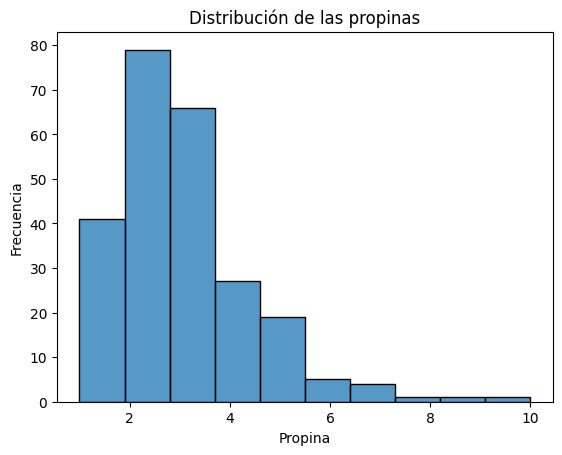

→ Las propinas se concentran en valores intermedios (2–4), con una distribución asimétrica hacia la derecha, donde las propinas altas son poco frecuentes


In [15]:
sns.histplot(df2['tip'], bins=10)
plt.title('Distribución de las propinas')
plt.xlabel('Propina')
plt.ylabel('Frecuencia')
plt.show()
print('→ Las propinas se concentran en valores intermedios (2–4), con una distribución asimétrica hacia la derecha, donde las propinas altas son poco frecuentes')

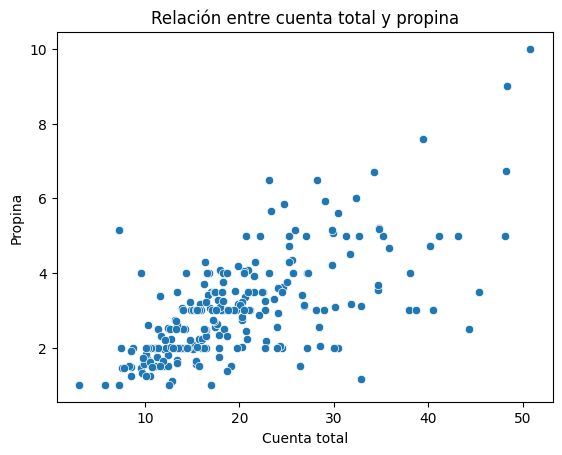

→ Correlación positiva moderada entre ambas variables - El monto de la cuenta influye en la propina pero no la determina


In [17]:
sns.scatterplot(x='total_bill', y='tip', data=df2)
plt.title('Relación entre cuenta total y propina')
plt.xlabel('Cuenta total')
plt.ylabel('Propina')
plt.show()
print('→ Correlación positiva moderada entre ambas variables - El monto de la cuenta influye en la propina pero no la determina')

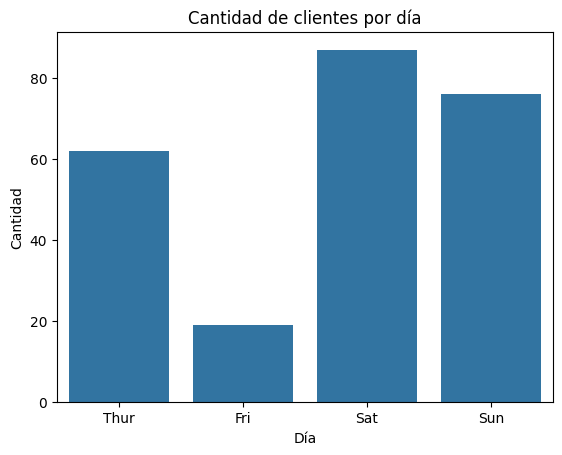

→ Los dias con mayor actividad son los sabados


In [19]:
sns.countplot(x='day', data=df2)
plt.title('Cantidad de clientes por día')
plt.xlabel('Día')
plt.ylabel('Cantidad')
plt.show()
print('→ Los dias con mayor actividad son los sabados')

**Conclusión 1**

---



El análisis de la distribución de las propinas muestra que la mayoría de los
valores se concentran en rangos intermedios, principalmente entre 2 y 4
unidades. La distribución presenta una asimetría positiva, evidenciando que las propinas más altas son menos frecuentes.

**Conclusión 2**


---


A partir del gráfico de dispersión, se observa una relación positiva entre el monto de la cuenta total y la propina. Esto indica que, en general, a mayor gasto, mayor es la propina, aunque con cierta variabilidad en los datos.

**Conclusión 3**


---


El análisis de la cantidad de clientes por día evidencia que la mayor actividad se concentra durante el fin de semana, especialmente los sábados, mientras que el viernes presenta la menor concurrencia.